# Grand-canonical grain-boundary optimization (Al, EAM, MD + relax)

Sample the lowest-energy grain-boundary microstructures by varying
the vacancy fraction on the GB plane, the in-plane translation
between the two crystallites, and the supercell replication. Each
candidate is **thermalised by a short MD run** and then relaxed under
BFGS — the MD step helps the candidate escape shallow local minima
before the final relaxation.

This notebook demonstrates the [`gco_search`](../pyiron_workflow_atomistics/physics/grand_canonical_gb.py)
workflow on an FCC-Al tilt boundary using the EAM `Al-Fe.eam.fs`
potential shipped with this repo. The algorithm is a port of
Chen & Frolov's GRIP ([Nat. Commun. **15**, 7049 (2024)](https://doi.org/10.1038/s41467-024-51330-9);
upstream: https://github.com/enze-chen/grip).

> **Cell convention:** with the default `vacuum=1.0` Å, the bicrystal
> cell has **two equivalent GB planes** — one at the stitch line and
> one across the z-periodic boundary. The 1 Å is intentionally too
> thin to be a real vacuum layer, making the cell a bulk-periodic
> stack of bicrystals. The GB-energy formula in
> `_grand_canonical_gb_code.gb_energy` therefore divides by
> `2 × area`. If you ever increase `vacuum` to make a true slab
> (`>15` Å), that formula will mix surface energy into `Egb`.
>
> **Caveat on absolute numbers:** `Al-Fe.eam.fs` is fit for the
> Al–Fe interaction; its pure-Al GB energies are an order-of-magnitude
> demonstration only. The notebook structure transfers directly to
> any other ASE-compatible calculator (MACE, CHGNet, MTP, …).

In [1]:
import pathlib

import matplotlib.pyplot as plt
from ase.calculators.eam import EAM
from ase.optimize import BFGS

from pyiron_workflow_atomistics.engine import (
    ASEEngine,
    CalcInputMD,
    CalcInputMinimize,
)
from pyiron_workflow_atomistics.physics.bulk import optimise_cubic_lattice_parameter
from pyiron_workflow_atomistics.physics.grand_canonical_gb import (
    GCOConfig,
    build_bicrystal_slabs,
    gco_search,
)
from pyiron_workflow_atomistics.structure import get_bulk

## 1. Build the engines

`gco_search` always runs a relaxation per iteration, and (when
supplied) an MD run before it. We therefore build **two** engines
under the same EAM potential — they share the calculator but carry
different `EngineInput` types:

- **minimize_engine** — `CalcInputMinimize(force_convergence_tolerance=0.001)`.
  Runs every iteration. `optimizer_kwargs={"logfile": None}` suppresses
  BFGS's per-step printouts to keep the notebook readable.
- **md_engine** — `CalcInputMD(mode="NVT", thermostat="langevin")`.
  `gco_search` overrides `temperature` and `n_ionic_steps` per iteration
  via `dataclasses.replace`, so the values below are just placeholders
  for the engine constructor.

In [2]:
pot_path = next(
    p
    for p in (pathlib.Path("Al-Fe.eam.fs"), pathlib.Path("notebooks/Al-Fe.eam.fs"))
    if p.exists()
)
calculator = EAM(potential=str(pot_path))

minimize_engine = ASEEngine(
    EngineInput=CalcInputMinimize(
        force_convergence_tolerance=0.001, max_iterations=500
    ),
    calculator=calculator,
    optimizer_class=BFGS,
    optimizer_kwargs={"logfile": None},
    working_directory="./_gco_aleam_runs",
    write_to_disk=False,
)

md_engine = ASEEngine(
    EngineInput=CalcInputMD(
        mode="NVT",
        thermostat="langevin",
        temperature=400.0,     # overridden per iter by gco_search
        n_ionic_steps=50,       # overridden per iter by gco_search
        time_step=1.0,          # fs
        thermostat_time_constant=100.0,  # fs
        seed=0,
    ),
    calculator=calculator,
    working_directory="./_gco_aleam_runs",
    write_to_disk=False,
)

## 2. Optimize the bulk reference under the same calculator

The GB-energy formula
$E_\mathrm{gb} = (E_\mathrm{total} - N\,E_\mathrm{coh})/(2 A)\, \times 16.0218 \; \mathrm{J/m^2}$
requires the bulk per-atom cohesive energy *under the same potential*
as the GB relaxation. We get it by running
[`optimise_cubic_lattice_parameter`](../pyiron_workflow_atomistics/physics/bulk.py) —
an EOS volume-scan macro that fits a Birch–Murnaghan EOS to a small
strain sweep and returns the equilibrium lattice parameter, bulk
modulus, per-atom energy, and per-atom volume.

In [3]:
al_guess = get_bulk.node_function("Al", crystalstructure="fcc", a=4.05, cubic=True)

bulk_wf = optimise_cubic_lattice_parameter(
    structure=al_guess,
    name="Al",
    crystalstructure="fcc",
    engine=minimize_engine.with_working_directory("bulk_opt"),
    rattle_amount=0.0,
    strain_range=(-0.02, 0.02),
    num_points=5,
)
bulk_wf.run()

a0 = bulk_wf.outputs.a0.value
e0_per_atom = bulk_wf.outputs.equil_energy_per_atom.value
B_GPa = bulk_wf.outputs.B.value
v0_per_atom = bulk_wf.outputs.equil_volume_per_atom.value

print(f"a0           = {a0:.4f} Å")
print(f"e_cohesive   = {e0_per_atom:.4f} eV/atom")
print(f"B            = {B_GPa:.1f} GPa")
print(f"v0           = {v0_per_atom:.3f} Å³/atom")

a0           = 4.0336 Å
e_cohesive   = -3.3697 eV/atom
B            = 80.4 GPa
v0           = 16.407 Å³/atom


## 3. Build matched upper / lower slabs

`build_bicrystal_slabs` constructs the two crystallites from a tilt
axis specified per slab. The two slabs here describe a Σ3 ⟨110⟩ tilt
boundary in FCC Al, using the optimized `a0` from step 2.

In [4]:
lower_slab, upper_slab, dlat = build_bicrystal_slabs.node_function(
    crystal="fcc",
    symbol="Al",
    a=a0,
    upper_dirs=[[1, 1, 0], [0, 0, 1], [1, -1, 0]],
    lower_dirs=[[1, -1, 0], [0, 0, 1], [-1, -1, 0]],
    cutoff=20.0,
)
print(f"lower: {len(lower_slab)} atoms")
print(f"upper: {len(upper_slab)} atoms")
print(f"dlat  = {dlat:.3f} Å")

lower: 16 atoms
upper: 16 atoms
dlat  = 1.426 Å


## 4. Configure the GCO search

Per-iteration MD parameters:

- `md_run_probability=1.0` — every iteration runs MD before the
  relaxation. Set < 1.0 for stochastic gating.
- `t_min`, `t_max` — random temperature in this range (multiples of
  100 K). Here both equal 400 K, so every MD runs at 400 K.
- `md_step_sampling="exact"` — every MD runs exactly `md_min_steps`
  steps (no random sweep). For demo speed.
- `md_min_steps=md_max_steps=50` — 50 × 1 fs = 50 fs of MD per iter.
  A real run would use 1–500 ps.

In [5]:
config = GCOConfig(
    # vacancy fraction on the GB plane: scan 0.5 .. 1.0
    frac_min=0.5,
    frac_max=1.0,
    # small supercells to keep the demo fast
    size0=(1, 1, 1),
    size=(1, 2, 5),
    reps_mode=2,  # uniform
    ngrid=10,
    # MD before every iteration
    md_run_probability=1.0,
    t_min=400,
    t_max=400,
    md_min_steps=50,
    md_max_steps=50,
    md_step_sampling="exact",
    # disable periodic dedup for clarity; n=3 is too short for it to matter
    dedup_every=0,
    # generous Egb gate so most converged iterations get kept
    e_mult=5.0,
)

## 5. Run the search

Each iteration now does:

1. Sample translation, replication, vacancy fraction
2. Stitch the bicrystal
3. **MD at 400 K for 50 fs** (`md_engine`)
4. Relax under BFGS to `fmax = 0.001 eV/Å` (`minimize_engine`)
5. Compute `Egb` and conditionally store

Returns `(DataFrame, list[ase.Atoms])`.

In [6]:
df, atoms_list = gco_search.node_function(
    minimize_engine=minimize_engine,
    md_engine=md_engine,
    lower_slab=lower_slab,
    upper_slab=upper_slab,
    dlat=dlat,
    e_cohesive=e0_per_atom,
    config=config,
    n_iters=3,
    seed=0,
)
print(f"Kept {len(df)} structures across 3 iterations:\n")
print(df[["iter", "Egb", "n", "rx", "ry", "T", "n_md_steps"]].to_string(index=False))

/home/liger/miniforge3/envs/test_pyiron_workflow_atomistics/lib/python3.11/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


Kept 3 structures across 3 iterations:

 iter      Egb   n  rx  ry   T  n_md_steps
    0 0.101962 0.0   1   1 400          50
    1 0.283826 0.5   1   2 400          50
    2 0.199803 0.0   1   1 400          50


## 6. Plot $E_\mathrm{gb}$ versus vacancy fraction

The classic GRIP output. With only 3 iterations the plot is sparse;
scaling to hundreds of iterations across multiple seeds (via
`for_node`) populates the n-vs-Egb curve properly.

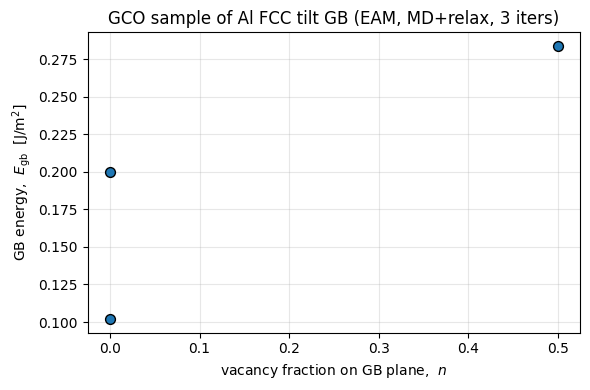


lowest Egb in this run: 0.102 J/m² (at iter=0)


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["n"], df["Egb"], s=50, edgecolor="black", zorder=3)
ax.set_xlabel("vacancy fraction on GB plane,  $n$")
ax.set_ylabel("GB energy,  $E_\\mathrm{gb}$  [J/m$^2$]")
ax.set_title("GCO sample of Al FCC tilt GB (EAM, MD+relax, 3 iters)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print(
    f"\nlowest Egb in this run: {df['Egb'].min():.3f} J/m² "
    f"(at iter={df.loc[df['Egb'].idxmin(), 'iter']})"
)

## Going further

- **Increase `n_iters` and sweep more `t_min/t_max`.** Real GCO runs
  often use `t_min=300, t_max=1200` with `md_step_sampling="exponential"`
  so the loop tries many short MDs and occasional long ones.
- **Try other potentials.** Swap `calculator=EAM(...)` for any other
  ASE-compatible calculator (MACE, CHGNet, MTP, …) — both engines
  share the calculator so a single substitution applies.
- **Parallelize across seeds.** Wrap `gco_search` in
  `for_node(gco_search, iter_on="seed", seed=range(N), ...)` to run
  N independent searches concurrently. This replaces GRIP's MPI
  launcher.